In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("fordgobike-tripdataFor201902.csv")
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  object 
 2   end_time                 183416 non-null  object 
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  object 
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  object 
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  object 
 13  member_birth_year        175151 non-null  float64
 14  memb

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [4]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

# Remove rows where time conversion failed
df = df.dropna(subset=['start_time', 'end_time'])

C:\Users\ahmed\AppData\Local\Temp\ipykernel_2764\964186566.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
C:\Users\ahmed\AppData\Local\Temp\ipykernel_2764\964186566.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')


In [5]:
df['member_birth_year'] = df['member_birth_year'].fillna(
    df['member_birth_year'].median()
)

df['member_gender'] = df['member_gender'].fillna("Unknown")

In [6]:
df['trip_duration_minutes'] = df['duration_sec'] / 60

In [7]:
df = df[df['trip_duration_minutes'] <= 60]

In [8]:
current_year = 2019
df['age'] = current_year - df['member_birth_year']

In [ ]:
df = df[(df['age'] >= 15) & (df['age'] <= 80)]

In [9]:
bins = [15, 25, 35, 45, 60, 80]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [10]:
df['weekday'] = df['start_time'].dt.day_name()

In [11]:
df['weekend_flag'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [12]:
df['user_type_encoded'] = df['user_type'].map({
    'Subscriber': 1,
    'Customer': 0
})

In [13]:
df['gender_encoded'] = df['member_gender'].map({
    'Male': 1,
    'Female': 0
})

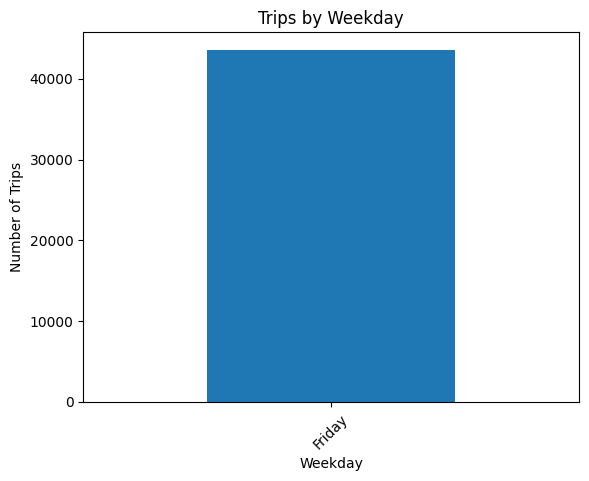

In [14]:
plt.figure()
df['weekday'].value_counts().plot(kind='bar')
plt.title("Trips by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

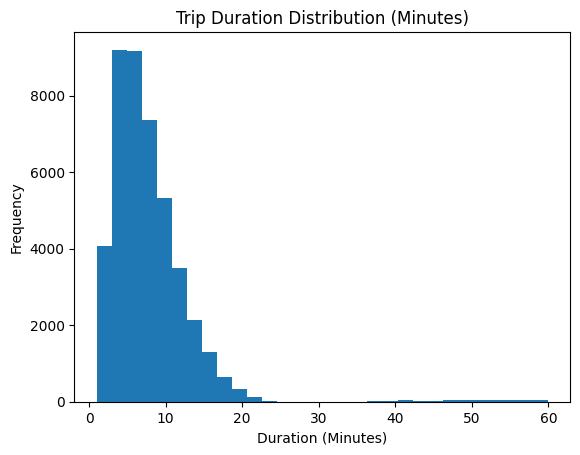

In [15]:
plt.figure()
plt.hist(df['trip_duration_minutes'], bins=30)
plt.title("Trip Duration Distribution (Minutes)")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

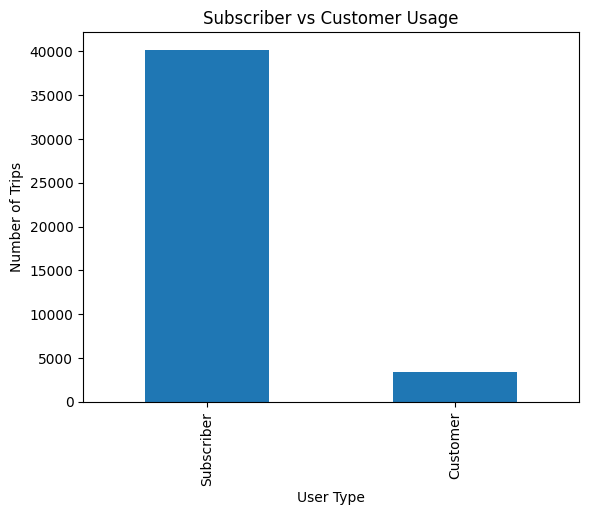

In [16]:
plt.figure()
df['user_type'].value_counts().plot(kind='bar')
plt.title("Subscriber vs Customer Usage")
plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.show()

In [17]:
df.to_csv("cleaned_fordgobike_201902.csv", index=False)